# Waze para La Estrella utilizando inteligencia artificial

## Fase 1: obtención y visualización del mapa

El objetivo del proyecto es desarrollar un método propio de búsqueda de rutas basado en A* para encontrar una ruta entre dos puntos de La Estrella, Antioquia. La función objetivo buscará minimizar el tiempo estimado de viaje en automóvil.

En esta primera fase se utilizará OSMnx para obtener la red vial de La Estrella como un grafo y mostrarla en un mapa.

### Importación de las bibliotecas

Se importan las bibliotecas empleadas en el ejemplo trabajado en clase. OSMnx permite obtener el mapa como un grafo con información geográfica de sus nodos y conexiones.

In [ ]:
%pip install geopy matplotlib networkx osmnx pandas plotly scikit-learn

In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString

import matplotlib.pyplot as plt
import plotly.express as px

import networkx as nx
import osmnx as ox
import heapq
import math
import time

## Mapa de La Estrella

La función `graph_from_place` recibe el nombre del lugar que se desea consultar. El parámetro `network_type='drive'` indica que se quieren obtener las vías disponibles para recorridos en automóvil.

El parámetro `simplify=False` permite conservar más puntos de la red vial, como se realizó en el ejemplo de clase. Esto ofrece una representación más detallada del recorrido de las calles.

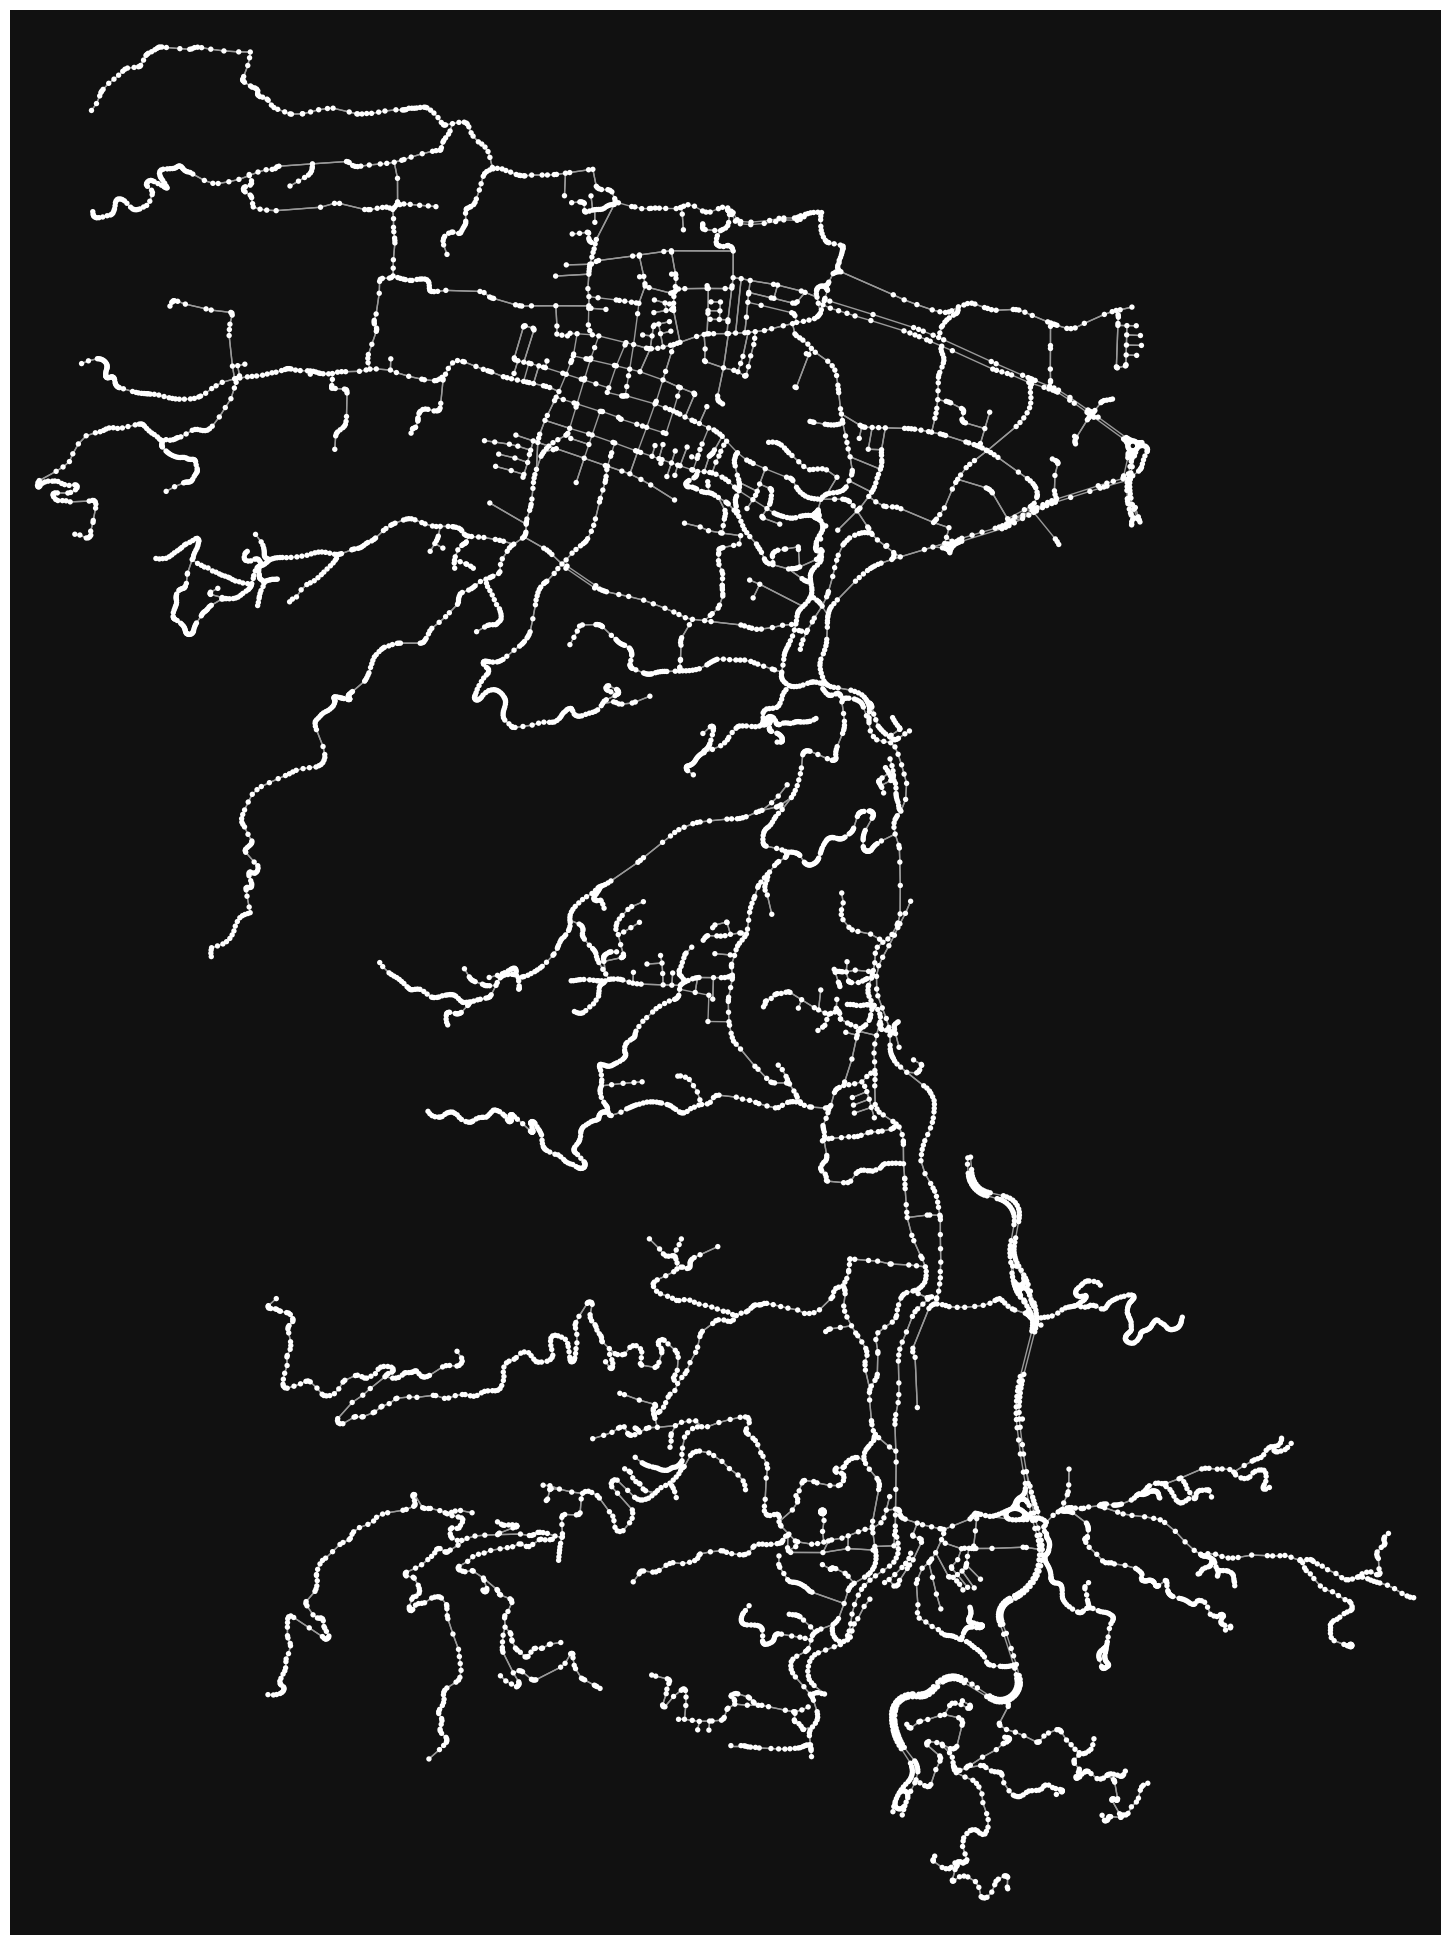

(<Figure size 2500x2500 with 1 Axes>, <Axes: >)

In [3]:
G = ox.graph_from_place('La Estrella, Antioquia, Colombia', network_type='drive', simplify=False)
ox.plot_graph(G, figsize=(25, 25))

### Información básica del mapa

El mapa se almacena en la variable `G`. Los nodos representan puntos de la red vial y las aristas representan las conexiones o tramos de calle entre esos puntos. Como se utilizó una red de tipo `drive`, se conservan los sentidos de circulación de las vías.

In [4]:
print('Cantidad de nodos:', len(G.nodes))
print('Cantidad de aristas:', len(G.edges))
print('Tipo de grafo:', type(G))

Cantidad de nodos: 7312
Cantidad de aristas: 13808
Tipo de grafo: <class 'networkx.classes.multidigraph.MultiDiGraph'>


## Resultado de la fase 1

Al finalizar esta fase se tiene en `G` el grafo de la red vial para automóviles de La Estrella y su representación gráfica. Este grafo será la base para seleccionar el origen y el destino y, posteriormente, implementar el algoritmo de búsqueda de rutas.

# Fase 2: definición del origen y el destino

En esta fase se localizarán los dos lugares de la demostración:

- **Origen:** unidad residencial Pitriza.
- **Destino:** Parque Comfama La Estrella.

Primero se obtendrán sus coordenadas geográficas y se comprobarán las direcciones encontradas. Después, cada ubicación se asociará con el nodo más cercano de la red vial `G`.

## Búsqueda de latitud y longitud

Como se trabajó en clase, se utilizará la biblioteca `geopy` con el servicio gratuito Nominatim para buscar la latitud y longitud de lugares específicos. El parámetro `user_agent` identifica la aplicación que realiza la consulta.

In [ ]:
%pip install geopy

In [6]:
import geopy
from geopy.geocoders import Nominatim

locator = Nominatim(user_agent='waze_ia_la_estrella')

Se consultan Pitriza y el Parque Comfama La Estrella. Nominatim puede no reconocer un nombre o devolver un lugar diferente, por lo que los resultados deben revisarse antes de continuar.

In [7]:
location_start = locator.geocode('Pitriza, La Estrella, Antioquia, Colombia')
location_end = locator.geocode('Parque Comfama La Estrella, Antioquia, Colombia')

if location_start is None:
    raise ValueError('Nominatim no encontró Pitriza. Se deben ingresar coordenadas verificadas manualmente.')

if location_end is None:
    raise ValueError('Nominatim no encontró el Parque Comfama La Estrella. Se deben ingresar coordenadas verificadas manualmente.')

## Verificación de las ubicaciones

Se muestran la dirección completa y las coordenadas encontradas. Antes de ejecutar las siguientes celdas se debe confirmar que ambas ubicaciones corresponden a los lugares esperados en La Estrella.

In [8]:
print('Origen encontrado:')
print(location_start.address)
print((location_start.latitude, location_start.longitude))

print('\nDestino encontrado:')
print(location_end.address)
print((location_end.latitude, location_end.longitude))

Origen encontrado:
Parque Pitriza, La Estrella, Valle de Aburrá, Antioquia, RAP del Agua y la Montaña, Colombia
(6.1562385, -75.6362846)

Destino encontrado:
PARQUE RECREATIVO COMFAMA LA ESTRELLA, #65a-296, La Estrella, Valle de Aburrá, Antioquia, RAP del Agua y la Montaña, 055467, Colombia
(6.1543088, -75.6531261)


Las coordenadas se guardan como tuplas en el orden `(latitud, longitud)`, de la misma manera utilizada en el ejemplo de clase.

In [9]:
start = (location_start.latitude, location_start.longitude)
end = (location_end.latitude, location_end.longitude)

print('Coordenadas del origen:', start)
print('Coordenadas del destino:', end)

Coordenadas del origen: (6.1562385, -75.6362846)
Coordenadas del destino: (6.1543088, -75.6531261)


## Asociación con la red vial

El algoritmo A* trabajará con identificadores de nodos y no directamente con coordenadas. La función `nearest_nodes` busca el nodo de `G` más cercano a cada lugar. OSMnx recibe primero la longitud (`X`) y después la latitud (`Y`), por eso se utilizan `start[1], start[0]` y `end[1], end[0]`.

In [ ]:
%pip install scikit-learn

In [11]:
start_node = ox.distance.nearest_nodes(G, start[1], start[0])
end_node = ox.distance.nearest_nodes(G, end[1], end[0])

print('Nodo vial del origen:', start_node)
print('Nodo vial del destino:', end_node)

Nodo vial del origen: 8449802805
Nodo vial del destino: 6128936619


## Visualización del origen y el destino

Se dibujan sobre el mapa los nodos viales seleccionados: Pitriza en rojo y Comfama en verde. Esta visualización permite comprobar que ambos puntos están ubicados correctamente antes de calcular una ruta.

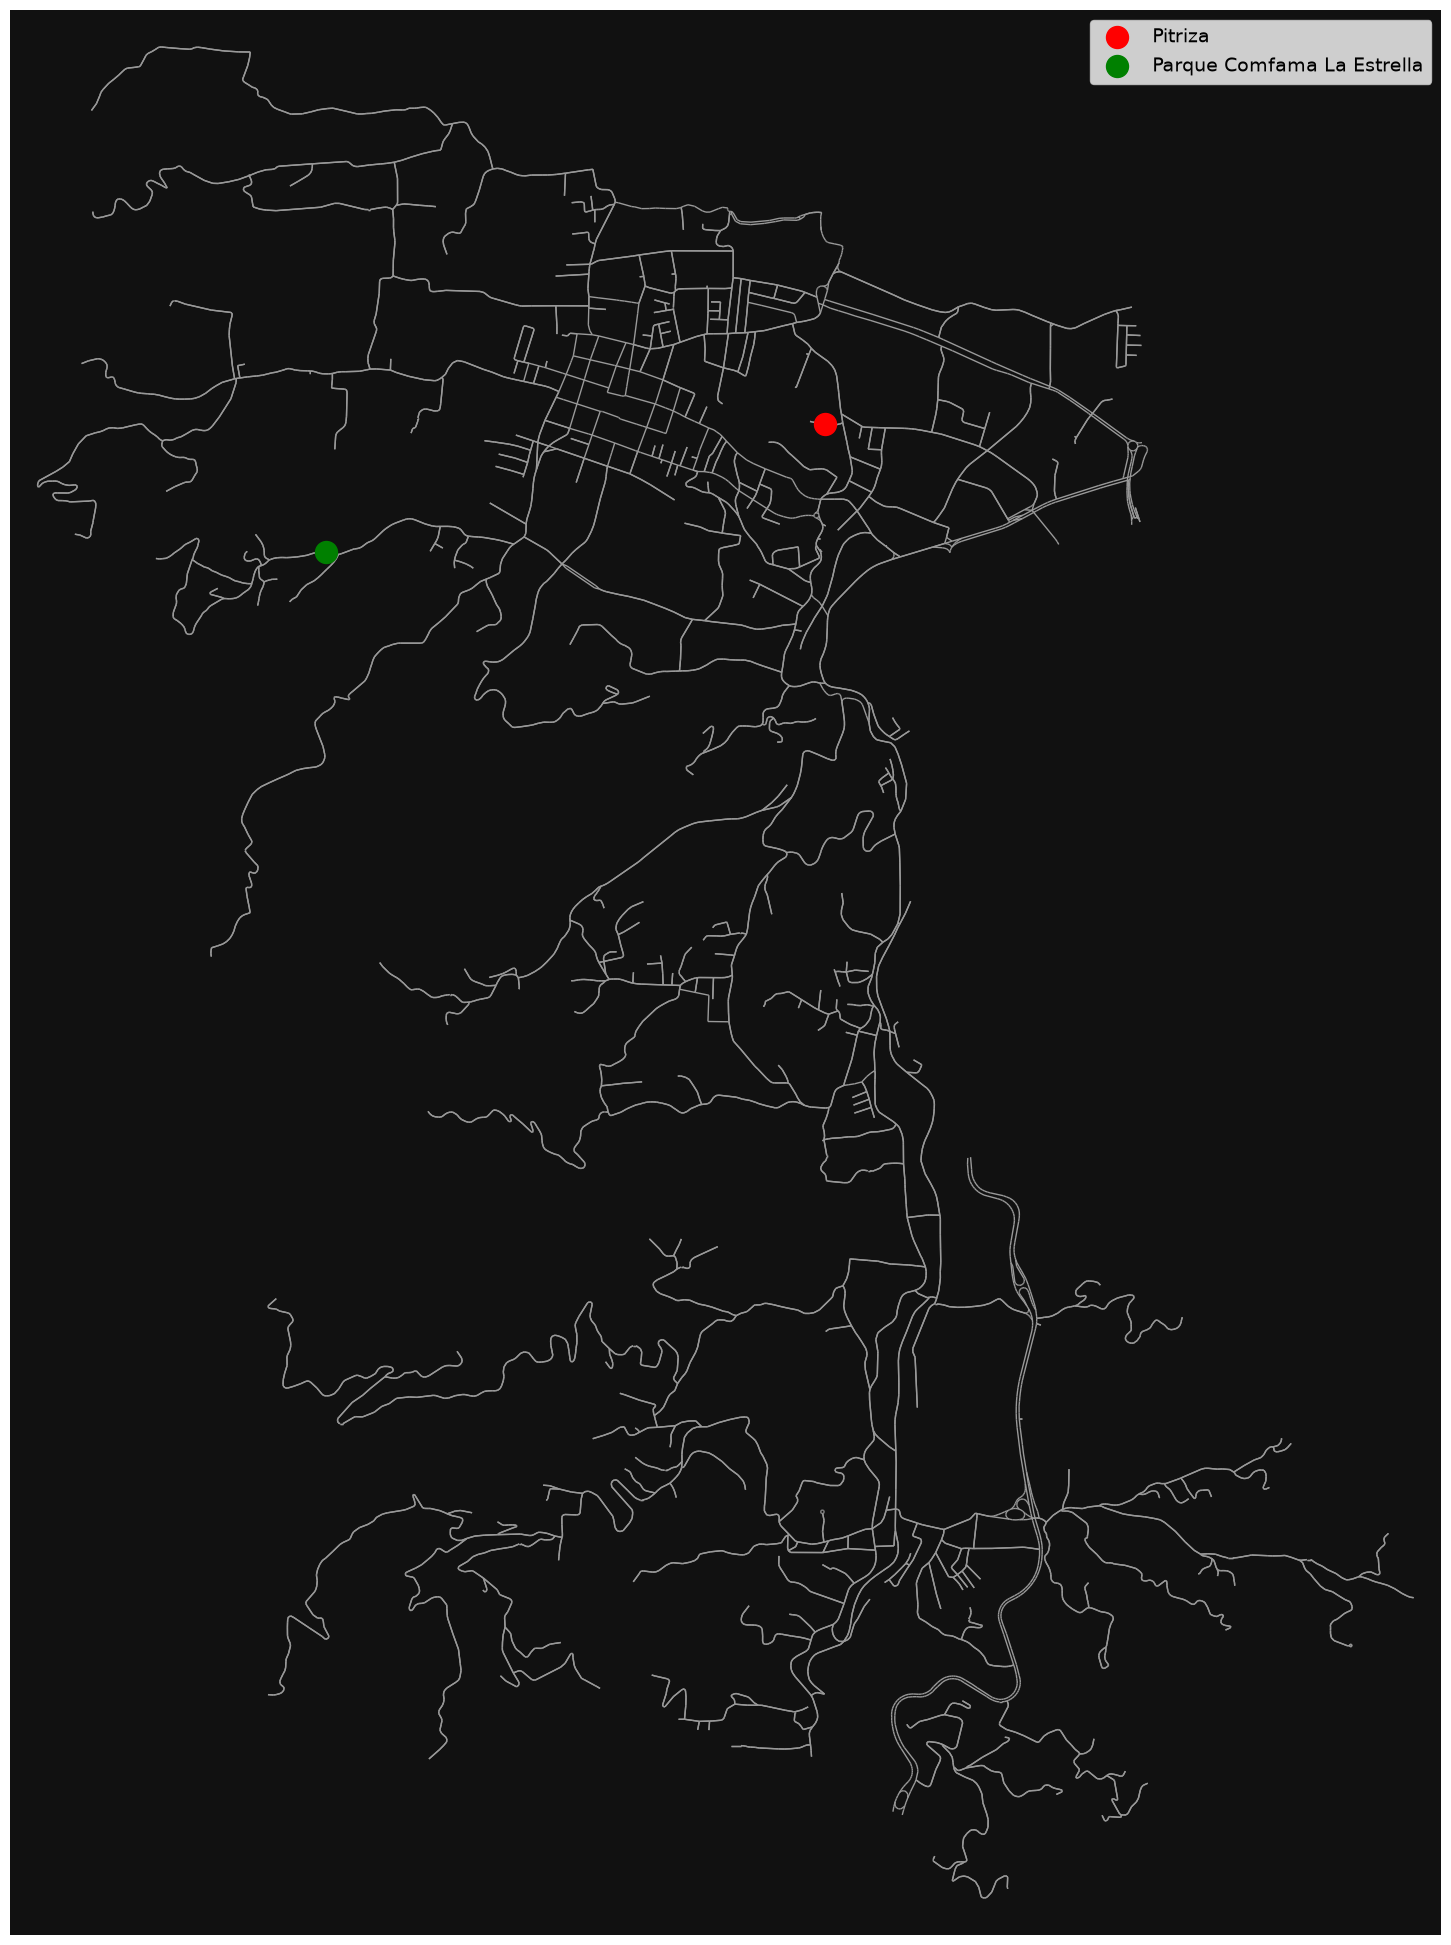

In [12]:
fig, ax = ox.plot_graph(G, figsize=(25, 25), node_size=0, show=False, close=False)

ax.scatter(G.nodes[start_node]['x'], G.nodes[start_node]['y'],
           c='red', s=250, label='Pitriza', zorder=3)
ax.scatter(G.nodes[end_node]['x'], G.nodes[end_node]['y'],
           c='green', s=250, label='Parque Comfama La Estrella', zorder=3)

ax.legend(fontsize=14)
plt.show()

## Resultado de la fase 2

Al finalizar esta fase quedan definidas las coordenadas `start` y `end`, junto con los nodos viales `start_node` y `end_node`. Estos identificadores serán el estado inicial y el estado objetivo de la búsqueda de rutas.

# Fase 3: preparación y revisión de los datos viales

En esta fase se preparan los datos que permitirán medir el costo de recorrer cada tramo de la red vial. El costo base será el tiempo estimado de viaje (`travel_time`), calculado a partir de la longitud de la calle y su velocidad estimada.

También se revisará cuánta información ofrece OpenStreetMap sobre las variables seleccionadas para el proyecto: distancia, velocidad, tiempo, tipo de vía, superficie y semáforos.

## Velocidades estimadas por tipo de vía

Algunas calles tienen el atributo `maxspeed`, pero otras no. Como se enseñó en clase, se crea un diccionario `hwy_speeds` con velocidades predeterminadas en kilómetros por hora. OSMnx utiliza estos valores para completar `speed_kph` cuando falta una velocidad.

Los valores son supuestos iniciales del modelo y se podrán ajustar posteriormente. No representan información de tráfico en tiempo real.

In [13]:
hwy_speeds = {
    'motorway': 80,
    'trunk': 60,
    'primary': 50,
    'secondary': 40,
    'tertiary': 35,
    'residential': 30,
    'unclassified': 30,
    'service': 20
}

hwy_speeds

{'motorway': 80,
 'trunk': 60,
 'primary': 50,
 'secondary': 40,
 'tertiary': 35,
 'residential': 30,
 'unclassified': 30,
 'service': 20}

## Cálculo de velocidad y tiempo de viaje

La función `add_edge_speeds` crea el atributo `speed_kph`. Después, `add_edge_travel_times` calcula el tiempo necesario para recorrer cada arista y lo guarda en `travel_time`, expresado en segundos.

No se sumarán distancia, velocidad y tiempo como costos independientes: el tiempo ya se calcula utilizando la distancia y la velocidad.

In [14]:
G = ox.add_edge_speeds(G, hwy_speeds=hwy_speeds)
G = ox.add_edge_travel_times(G)

print('Velocidades y tiempos de viaje calculados correctamente.')

Velocidades y tiempos de viaje calculados correctamente.


## Información de nodos y aristas

Como en el ejemplo de clase, `graph_to_gdfs` convierte el grafo en dos tablas geográficas: `gdf_nodes` para los nodos y `gdf_edges` para las calles.

In [15]:
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)
gdf_edges.head()

osmid     highway lanes maxspeed  \
u         v           key                                          
322010859 11933215278 0     440843501       trunk     3       80   
322010907 9369408441  0     384110369       trunk     2       80   
          9392365640  0    1018297125  trunk_link     1      NaN   
322010909 11933215257 0     384110369       trunk     2       80   
322010911 4121909108  0     384110369       trunk     2       80   

                                         name  oneway  ref  reversed  \
u         v           key                                              
322010859 11933215278 0    Avenida Carrera 42    True   25     False   
322010907 9369408441  0    Avenida Carrera 42    True   25     False   
          9392365640  0                   NaN    True  NaN     False   
322010909 11933215257 0    Avenida Carrera 42    True   25     False   
322010911 4121909108  0    Avenida Carrera 42    True   25     False   

                              length  speed_kph  travel_time bridge width  \
u         v           key                                                   
322010859 11933215278 0    19.641968  80.000000     0.883889    NaN   NaN   
322010907 9369408441  0    35.111248  80.000000     1.580006    NaN   NaN   
          9392365640  0    37.208254  40.318182     3.322315    NaN   NaN   
322010909 11933215257 0    20.267521  80.000000     0.912038    NaN   NaN   
322010911 4121909108  0    60.862245  80.000000     2.738801    NaN   NaN   

                          junction access  \
u         v           key                   
322010859 11933215278 0        NaN    NaN   
322010907 9369408441  0        NaN    NaN   
          9392365640  0        NaN    NaN   
322010909 11933215257 0        NaN    NaN   
322010911 4121909108  0        NaN    NaN   

                                                                    geometry  
u         v           key                                                     
322010859 11933215278 0    LINESTRING (-75.62853 6.15432, -75.62869 6.15424)  
322010907 9369408441  0    LINESTRING (-75.62939 6.15377, -75.62967 6.15363)  
          9392365640  0     LINESTRING (-75.62939 6.15377, -75.62972 6.1537)  
322010909 11933215257 0    LINESTRING (-75.62839 6.15428, -75.62856 6.15421)  
322010911 4121909108  0    LINESTRING (-75.62774 6.15449, -75.62826 6.15433)

La siguiente tabla resume la longitud, velocidad y tiempo promedio según el tipo de vía. Sigue el mismo análisis realizado en el cuaderno trabajado en clase.

In [16]:
gdf_edges.explode('highway').groupby('highway')[['length', 'speed_kph', 'travel_time']].mean().round(1)

,length,speed_kph,travel_time
highway,,,
residential,16.9,30.0,2.0
secondary,22.4,39.7,2.1
secondary_link,7.2,30.0,0.9
tertiary,20.5,33.4,2.3
tertiary_link,6.1,28.2,0.8
trunk,18.8,40.5,1.8
trunk_link,11.2,40.3,1.0
unclassified,18.7,30.0,2.2


## Revisión de la cobertura de los atributos

Antes de utilizar un atributo en el modelo se debe comprobar si está presente en suficientes calles. La tabla muestra cuántas aristas tienen cada variable y qué porcentaje representan dentro de la red.

In [17]:
atributos_viales = ['length', 'speed_kph', 'travel_time', 'highway', 'surface']
cantidad_aristas = len(gdf_edges)
cobertura = []

for atributo in atributos_viales:
    if atributo in gdf_edges.columns:
        datos_disponibles = int(gdf_edges[atributo].notna().sum())
    else:
        datos_disponibles = 0

    cobertura.append({
        'atributo': atributo,
        'datos disponibles': datos_disponibles,
        'datos faltantes': cantidad_aristas - datos_disponibles,
        'cobertura (%)': round(datos_disponibles / cantidad_aristas * 100, 2)
    })

tabla_cobertura = pd.DataFrame(cobertura)
tabla_cobertura

,atributo,datos disponibles,datos faltantes,cobertura (%)
0,length,13808,0,100.0
1,speed_kph,13808,0,100.0
2,travel_time,13808,0,100.0
3,highway,13808,0,100.0
4,surface,0,13808,0.0


## Tipos de vía encontrados

OpenStreetMap puede guardar `highway` como un texto o como una lista cuando un tramo reúne varias clasificaciones. Por eso se normalizan los valores antes de contarlos.

In [18]:
def normalizar_valor_osm(valor):
    if isinstance(valor, list):
        return ', '.join(map(str, valor))
    return valor

tipos_via = gdf_edges['highway'].apply(normalizar_valor_osm).value_counts(dropna=False)
tipos_via.to_frame(name='cantidad de aristas')

,cantidad de aristas
highway,
residential,10014
unclassified,1474
tertiary,1266
secondary,495
trunk,420
trunk_link,122
tertiary_link,13
secondary_link,4


## Superficies encontradas

La superficie solo se incorporará al costo si existe información suficiente. Si la columna no aparece, significa que ninguna arista descargada contiene este atributo.

In [19]:
if 'surface' in gdf_edges.columns:
    superficies = gdf_edges['surface'].apply(normalizar_valor_osm).value_counts(dropna=False)
    display(superficies.to_frame(name='cantidad de aristas'))
else:
    print('OpenStreetMap no proporcionó información de superficie para las aristas descargadas.')

OpenStreetMap no proporcionó información de superficie para las aristas descargadas.


## Semáforos registrados

Los semáforos se identifican en los nodos mediante `highway='traffic_signals'`. Por ahora únicamente se cuentan; su demora se incorporará progresivamente después de validar el algoritmo A* básico.

In [20]:
def es_semaforo(datos_nodo):
    valor = datos_nodo.get('highway')
    if isinstance(valor, list):
        return 'traffic_signals' in valor
    return valor == 'traffic_signals'

nodos_semaforo = [
    nodo for nodo, datos in G.nodes(data=True)
    if es_semaforo(datos)
]

print('Cantidad de semáforos registrados:', len(nodos_semaforo))

Cantidad de semáforos registrados: 6


## Reglas para los datos faltantes

Para mantener un modelo reproducible se utilizarán estas reglas iniciales:

- **Longitud:** OSMnx calcula `length` para todas las aristas al construir el grafo.
- **Velocidad:** si falta `maxspeed`, se estima `speed_kph` con el diccionario `hwy_speeds`; OSMnx completa otros casos con valores representativos de la red.
- **Tiempo:** se calcula en segundos a partir de `length` y `speed_kph`.
- **Tipo de vía:** se conserva el atributo `highway` de OpenStreetMap.
- **Superficie:** inicialmente se considera sin penalización cuando falta el dato. Solo se usará si su cobertura resulta suficiente.
- **Semáforos:** se utilizan únicamente los registrados en OpenStreetMap; la ausencia de una etiqueta no demuestra que no exista un semáforo real.
- **Pendiente:** no se calcula todavía porque requiere incorporar elevaciones desde otra fuente.

## Resultado de la fase 3

Al finalizar esta fase, cada arista del grafo `G` tiene una velocidad estimada (`speed_kph`) y un tiempo de viaje (`travel_time`). Además, `tabla_cobertura`, `tipos_via`, `nodos_semaforo` y el análisis de superficies permiten decidir qué atributos pueden incorporarse de forma responsable al modelo de rutas.

# Fase 4: creación de la clase `OSMRouteMap`

La clase `OSMRouteMap` adapta la idea de `RouteMap` del cuaderno trabajado en clase a una red vial de OpenStreetMap. En este caso, cada estado es el identificador de un nodo de `G` y los operadores son las aristas dirigidas que salen de él.

A diferencia del mapa pequeño del ejemplo, `G` es un `MultiDiGraph`: puede haber varias aristas entre los mismos dos nodos. Por eso cada vecino conserva también la clave (`key`) de la arista que lo conecta.

## Costos y heurística

### Costo de las aristas

La función `edge_travel_cost` utiliza actualmente el atributo `travel_time` proporcionado por OSMnx como costo de cada arista. Por lo tanto, todos los costos se expresan en **segundos** y representan el tiempo estimado necesario para recorrer cada tramo de la red vial.

En esta fase no se aplican penalizaciones adicionales. La clase conserva una configuración (`config`) que permitirá incorporar posteriormente factores como semáforos, tipo de vía o superficie sin modificar la interfaz principal de `OSMRouteMap`.

### Heurística

La función heurística estima el tiempo mínimo restante entre un nodo y el destino. Para ello, primero calcula la distancia geográfica en línea recta entre ambos nodos mediante la **fórmula de Haversine** y posteriormente convierte esa distancia en un tiempo utilizando la mayor velocidad disponible en el grafo:


$h(n) = \frac{d(n, destino)}{v_{\\max}}$


donde:

- d(n, destino) es la distancia en línea recta entre el nodo actual y el destino.
- v_max es la mayor velocidad registrada en la red vial.
- h(n) es el tiempo estimado restante, expresado en segundos.

Esta elección busca que la heurística sea **admisible** para A*. La distancia en línea recta es una cota inferior de cualquier distancia que deba recorrerse utilizando la red vial, mientras que utilizar la velocidad máxima produce el menor tiempo posible para recorrer dicha distancia. Por esta razón, la estimación no sobreestima el costo real de alcanzar el destino:


$h(n) \leq h^*(n)$


donde $h^*(n)$ representa el costo real mínimo desde el nodo $n$ hasta el destino.

La heurística, por tanto, proporciona una estimación optimista del tiempo restante sin incorporar todavía factores adicionales como semáforos, pendientes o condiciones de la superficie.


In [21]:
class OSMRouteMap:
    """
    Consultas, costos y heurística para una red vial dirigida
    obtenida de OpenStreetMap mediante OSMnx.

    La función objetivo es minimizar el tiempo estimado de viaje
    en automóvil.
    """

    def __init__(self, graph, config=None):
        self.graph = graph
        self.config = dict(config) if config is not None else {}

        # Velocidad máxima utilizada por la heurística.
        #
        # Si no se especifica, se obtiene de las aristas del grafo.
        if 'max_speed_kph' in self.config:
            self.max_speed_kph = float(self.config['max_speed_kph'])
        else:
            self.max_speed_kph = self._maximum_speed_kph()

        if (
            not math.isfinite(self.max_speed_kph)
            or self.max_speed_kph <= 0
        ):
            raise ValueError(
                'max_speed_kph debe ser un número positivo.'
            )

    @staticmethod
    def _as_numbers(value):
        """
        Convierte valores simples o listas de OSM en números válidos.

        OSM puede almacenar algunos atributos como:
            30
            '30'
            ['30', '40']
        """
        values = (
            value
            if isinstance(value, (list, tuple))
            else [value]
        )

        numbers = []

        for item in values:
            try:
                number = float(item)
            except (TypeError, ValueError):
                continue

            if math.isfinite(number):
                numbers.append(number)

        return numbers

    def _maximum_speed_kph(self):
        """
        Obtiene la mayor velocidad válida presente en las aristas.

        Esta velocidad se utiliza como referencia para construir
        la heurística temporal.
        """
        speeds = []

        for _, _, edge_data in self.graph.edges(data=True):
            speeds.extend(
                self._as_numbers(
                    edge_data.get('speed_kph')
                )
            )

        if not speeds:
            raise ValueError(
                'El grafo no contiene valores válidos de speed_kph.'
            )

        return max(speeds)

    def neighbors(self, node_id):
        """
        Devuelve las aristas salientes de node_id.

        Cada elemento tiene la forma:

            (neighbor_id, key, edge_data)

        Se utilizan out_edges() y keys=True para:
        - respetar el sentido de circulación;
        - conservar las aristas paralelas.
        """
        return [
            (neighbor_id, key, edge_data)
            for _, neighbor_id, key, edge_data
            in self.graph.out_edges(
                node_id,
                keys=True,
                data=True
            )
        ]

    def edge_travel_cost(
        self,
        u,
        v,
        key,
        edge_data
    ):
        """
        Devuelve el costo de recorrer una arista en segundos.

        El costo corresponde directamente a travel_time,
        calculado previamente por OSMnx.
        """
        travel_times = self._as_numbers(
            edge_data.get('travel_time')
        )

        if not travel_times:
            raise ValueError(
                f'La arista ({u}, {v}, {key}) '
                'no tiene un travel_time válido.'
            )

        travel_time = travel_times[0]

        if travel_time < 0:
            raise ValueError(
                f'La arista ({u}, {v}, {key}) '
                'tiene un costo negativo.'
            )

        return travel_time

    def heuristic(self, node_id, destination_id):
        """
        Estima en segundos el tiempo mínimo restante desde
        node_id hasta destination_id.

        La estimación se obtiene mediante:

            distancia en línea recta / velocidad máxima

        La distancia se calcula mediante la fórmula de Haversine.

        Utilizar la distancia en línea recta proporciona una
        distancia mínima posible entre ambos nodos. Utilizar la
        velocidad máxima proporciona el menor tiempo físicamente
        posible bajo el modelo utilizado.

        Por tanto, la heurística no sobreestima el tiempo real
        de viaje y es admisible para A* bajo este modelo.
        """
        if node_id == destination_id:
            return 0.0

        origin = self.graph.nodes[node_id]
        destination = self.graph.nodes[destination_id]

        # Coordenadas geográficas de los nodos.
        lat1 = math.radians(origin['y'])
        lon1 = math.radians(origin['x'])

        lat2 = math.radians(destination['y'])
        lon2 = math.radians(destination['x'])

        # Diferencias angulares.
        delta_lat = lat2 - lat1
        delta_lon = lon2 - lon1

        # Fórmula de Haversine.
        a = (
            math.sin(delta_lat / 2) ** 2
            + math.cos(lat1)
            * math.cos(lat2)
            * math.sin(delta_lon / 2) ** 2
        )

        # Evita pequeños errores numéricos fuera del intervalo [0, 1].
        a = min(1.0, max(0.0, a))

        earth_radius_m = 6_371_008.8

        distance_m = (
            2
            * earth_radius_m
            * math.asin(math.sqrt(a))
        )

        # Conversión:
        #
        # distancia_m / (km/h)
        # ->
        # segundos
        #
        # 1 km/h = 1/3.6 m/s
        estimated_time_s = (
            distance_m * 3.6 / self.max_speed_kph
        )

        return estimated_time_s

    def a_star(self, start_id, destination_id):
        """
        Se implementará en la Fase 5 mediante una cola
        de prioridad propia.
        """
        raise NotImplementedError(
            'A* se implementará en la Fase 5.'
        )

    def reconstruct_route(
        self,
        came_from,
        destination_id
    ):
        """
        Se implementará en la Fase 5.
        """
        raise NotImplementedError(
            'La reconstrucción se implementará en la Fase 5.'
        )

## Resultado de la fase 4

`OSMRouteMap` ya permite consultar únicamente las aristas alcanzables, distinguir aristas paralelas, obtener el costo temporal de cada tramo y estimar el tiempo restante hasta un destino. La búsqueda A* y la reconstrucción de la ruta se desarrollarán en la siguiente fase.